# Evaporators: single effect, multiple effect, MVR

This notebook walks through `Evaporator`, `MultiEffectEvaporator` and
`MechanicalVaporRecompression`, and ends with a gradient-based study of the
optimal number of effects.

**What this notebook is and is not.** The balances close and the gradients are
checked (`tests/test_evaporator.py`), but no textbook worked example is claimed
to be reproduced, the NaOH/NaCl/sucrose Duhring data built into the library are
unverified recollections, and the prices in section 6 are **illustrative
placeholders, not market data**. The system studied uses the `ideal` (Raoult)
boiling-point-rise model, which carries no tabulated data.

In [1]:
import warnings
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from difflow import (
    make_stream, Evaporator, EvaporatorParams,
    MultiEffectEvaporator, MultiEffectEvaporatorParams,
    MechanicalVaporRecompression, MVRParams,
)
from difflow.economics.capital import heat_exchanger_cost

# 2 kg/s of 10 wt % NaOH in water, 330 K. The solute is an ordinary species
# whose vapor flow is zero: the vapor outlet carries F_NaOH = 0.
F, xF = 2.0, 0.10
feed = make_stream({"water": F * (1 - xF) * 1000 / 18.015,
                    "NaOH": F * xF * 1000 / 40.0}, T=330.0, P=2e5)
NAOH = dict(solute_species=["NaOH"], solute_MW=[40.0],
            bpr_model="ideal", vant_hoff_i=2.0)   # Raoult, NaOH -> 2 particles

## 1. Single effect: design and rating

*Design*: give the product concentration, get steam, duty and area.
*Rating*: give the area, get the product concentration back.

In [2]:
params = EvaporatorParams(**NAOH, U=1500.0, x_product=0.30,
                          P_vapor_space=30e3, steam_P=300e3)
conc, vap, info = Evaporator(params)(feed)
for k in ["steam", "steam_economy", "Q", "A", "T_soln", "BPR", "driving_force"]:
    print(f"{k:15s} {float(info[k]):12.4g}")
print("vapor carries NaOH:", float(vap["F_NaOH"]), "mol/s")
print("closure: energy", float(info["energy_balance_error"]), "W, mass",
      float(info["mass_balance_error"]), "kg/s")

rating = EvaporatorParams(**NAOH, U=1500.0, A=float(info["A"]),
                          P_vapor_space=30e3, steam_P=300e3)
_, _, back = Evaporator(rating)(feed)
print("rating the designed area gives x_P =", round(float(back["x_product"]), 6))

steam                  1.502
steam_economy         0.8876
Q                  3.248e+06
A                      38.17
T_soln                 349.9
BPR                    7.696
driving_force          56.73
vapor carries NaOH: 0.0 mol/s
closure: energy 0.0 W, mass 0.0 kg/s


rating the designed area gives x_P = 0.3


## 2. What the boiling-point rise costs

The same duty with and without the BPR: the vapor leaves superheated, and the
driving force `T_steam - T_soln` shrinks, so the area grows.

In [3]:
for model in ["none", "ideal"]:
    p = EvaporatorParams(**{**NAOH, "bpr_model": model}, U=1500.0, x_product=0.30,
                         P_vapor_space=30e3, steam_P=300e3)
    i = Evaporator(p)(feed)[2]
    print(f"bpr_model={model:6s} BPR={float(i['BPR']):5.1f} K   dT={float(i['driving_force']):5.1f} K"
          f"   area={float(i['A']):6.1f} m2   steam={float(i['steam']):.3f} kg/s")

bpr_model=none   BPR=  0.0 K   dT= 64.4 K   area=  33.2 m2   steam=1.485 kg/s
bpr_model=ideal  BPR=  7.7 K   dT= 56.7 K   area=  38.2 m2   steam=1.502 kg/s


## 3. Triple effect, three feed arrangements, equal areas

Design mode solves the effect temperatures, vapor flows, steam rate and one
common area together (one Newton solve).

In [4]:
def mee(N, arrangement="forward", **kw):
    base = dict(NAOH, n_effects=N, feed=arrangement, U=[2500.0, 2000.0, 1500.0, 1200.0, 1000.0, 900.0][:N],
                x_product=0.30, P_vapor_space=30e3, steam_P=300e3)
    base.update(kw)
    return MultiEffectEvaporator(MultiEffectEvaporatorParams(**base))

for arrangement in ["forward", "backward", "parallel"]:
    c, v, i = mee(3, arrangement)(feed)
    print(f"{arrangement:9s} converged={bool(i['converged'])}  steam={float(i['steam']):.3f} kg/s  "
          f"economy={float(i['steam_economy']):.2f}  A each={float(i['A'][0]):6.1f} m2  "
          f"T=[{', '.join(f'{float(t):.1f}' for t in i['T'])}] K")

forward   converged=True  steam=0.636 kg/s  economy=2.10  A each=  34.8 m2  T=[390.9, 374.2, 349.9] K


backward  converged=True  steam=0.572 kg/s  economy=2.33  A each=  36.9 m2  T=[393.3, 367.8, 345.0] K


parallel  converged=True  steam=0.584 kg/s  economy=2.28  A each=  45.6 m2  T=[395.6, 373.5, 349.9] K


## 4. Steam economy versus number of effects

For a water-like solution with a preheated feed the economy is close to `N`
and sags as N grows; with a real BPR and a cold feed it is lower.

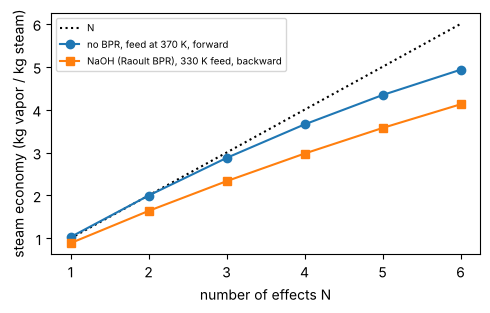

economy/N, no BPR: [1.03, 1.0, 0.96, 0.91, 0.87, 0.82]


In [5]:
Ns = range(1, 7)
cold = [float(mee(N, "backward")(feed)[2]["steam_economy"]) for N in Ns]
hot_feed = make_stream({k[2:]: v for k, v in feed.items() if k.startswith("F_")}, T=370.0, P=2e5)
water_like = [float(mee(N, "forward", bpr_model="none", x_product=0.2, U=[2500.0],
                        P_vapor_space=20e3, steam_P=400e3)(hot_feed)[2]["steam_economy"]) for N in Ns]
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(list(Ns), list(Ns), "k:", label="N")
ax.plot(list(Ns), water_like, "o-", label="no BPR, feed at 370 K, forward")
ax.plot(list(Ns), cold, "s-", label="NaOH (Raoult BPR), 330 K feed, backward")
ax.set_xlabel("number of effects N"); ax.set_ylabel("steam economy (kg vapor / kg steam)")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()
print("economy/N, no BPR:", [round(e / n, 2) for n, e in zip(Ns, water_like)])

## 5. Gradients through the solve

The multi-effect solve is a Newton root find differentiated by the implicit
function theorem, so `jax.grad` works through the whole design.

In [6]:
def design(U1, xF_, Ps):
    m = mee(3, "forward", U=[U1, 0.8 * U1, 0.6 * U1], steam_P=Ps)
    fd = make_stream({"water": F * (1 - xF_) * 1000 / 18.015, "NaOH": F * xF_ * 1000 / 40.0}, T=330.0, P=2e5)
    i = m(fd)[2]
    return jnp.stack([i["steam"], i["A"][0]])

x0 = (2500.0, 0.10, 300e3)
J = jax.jacrev(design, argnums=(0, 1, 2))(*x0)
names = ["U1 (W/m2/K)", "feed x_solute", "steam P (Pa)"]
for n, g in zip(names, J):
    print(f"d[steam, area]/d {n:14s} = {np.asarray(g)}")
print("(more U or more steam pressure lowers the area; a more concentrated feed needs less steam and area)")

d[steam, area]/d U1 (W/m2/K)    = [-2.57286258e-20 -1.39304401e-02]
d[steam, area]/d feed x_solute  = [  -2.54181316 -122.51654561]
d[steam, area]/d steam P (Pa)   = [ 2.60387881e-07 -8.06024157e-05]
(more U or more steam pressure lowers the area; a more concentrated feed needs less steam and area)


## 6. Optimal number of effects

Trade capital against steam. **Every price below is an illustrative
placeholder, not market data**: the steam price ($/tonne) is a made-up linear
function of pressure, installed cost is `capital_factor` times the library's
shell-and-tube `heat_exchanger_cost` per effect (a stand-in for a real
evaporator cost curve, which is not in difflow), the annualization is 20 %/yr
and the plant runs 8000 h/yr.

For each N = 1..6 the **continuous steam pressure** is optimized with L-BFGS-B
using `jax.value_and_grad` through the multi-effect solve (bounds 150-600 kPa).
N itself is discrete, so it is scanned rather than relaxed. The optimum N moves
with the placeholders, which is the point of the second scenario. In both
scenarios the 150 kPa lower bound on the steam pressure is active for most N
(a bound-active optimum: the gradient points to lower pressure all the way
down), so the real optimization content is the scan over N.

In [7]:
HOURS, ANNUAL = 8000.0, 0.20

def annual_cost(N, Ps_kPa, capital_factor, steam_base):
    m = mee(N, "backward", U=[2000.0], steam_P=Ps_kPa * 1e3)
    i = m(feed)[2]
    capital = capital_factor * N * heat_exchanger_cost(i["A"][0])          # $ (placeholder factor)
    price = steam_base + 0.04 * Ps_kPa                                      # $/tonne (placeholder)
    steam = i["steam"] * 3600.0 * HOURS / 1000.0 * price                    # $/yr
    return ANNUAL * capital + steam, (capital, steam, i["A"][0])

def scan(capital_factor, steam_base):
    rows = []
    for N in range(1, 7):
        vg = jax.jit(jax.value_and_grad(lambda u: annual_cost(N, u[0], capital_factor, steam_base)[0]))
        fun = lambda u: (lambda v: (float(v[0]), np.asarray(v[1])))(vg(jnp.asarray(u)))
        r = minimize(fun, [300.0], jac=True, method="L-BFGS-B", bounds=[(150.0, 600.0)])
        cost, (cap, st, A) = annual_cost(N, r.x[0], capital_factor, steam_base)
        rows.append((N, float(r.x[0]), float(cost), float(cap), float(st), float(A)))
    return rows

results = {}
for label, (cf, sb) in {"A: capital factor 10, steam $8/t + 0.04/kPa": (10.0, 8.0),
                        "B: capital factor 30, steam $10/t + 0.04/kPa": (30.0, 10.0)}.items():
    rows = scan(cf, sb)
    results[label] = rows
    best = min(rows, key=lambda r: r[2])
    print(label)
    print("  N   Ps_opt(kPa)   annual cost ($M/yr)   capital ($M)   steam ($M/yr)   area each (m2)")
    for N, P, c, cap, st, A in rows:
        print(f"  {N}   {P:9.1f}   {c/1e6:14.3f}   {cap/1e6:14.3f}   {st/1e6:12.3f}   {A:10.1f}" + ("   <- best" if N == best[0] else ""))

A: capital factor 10, steam $8/t + 0.04/kPa
  N   Ps_opt(kPa)   annual cost ($M/yr)   capital ($M)   steam ($M/yr)   area each (m2)
  1       150.0            0.627            0.195          0.588         47.0
  2       150.0            0.388            0.398          0.308         54.7
  3       150.0            0.335            0.612          0.212         63.8
  4       150.0            0.332            0.840          0.164         75.8   <- best
  5       150.0            0.353            1.091          0.134         93.0
  6       173.5            0.387            1.308          0.126         92.7


B: capital factor 30, steam $10/t + 0.04/kPa
  N   Ps_opt(kPa)   annual cost ($M/yr)   capital ($M)   steam ($M/yr)   area each (m2)
  1       150.0            0.789            0.584          0.672         47.0
  2       150.0            0.591            1.195          0.352         54.7   <- best
  3       150.0            0.610            1.836          0.242         63.8
  4       161.1            0.690            2.483          0.194         69.5
  5       203.4            0.792            3.052          0.182         62.8
  6       248.9            0.903            3.623          0.178         58.7


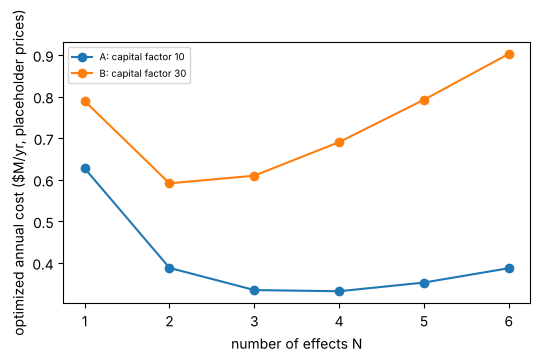

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 3.4))
for label, rows in results.items():
    ax.plot([r[0] for r in rows], [r[2] / 1e6 for r in rows], "o-", label=label[:2] + label[2:].split(",")[0])
ax.set_xlabel("number of effects N"); ax.set_ylabel("optimized annual cost ($M/yr, placeholder prices)")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

## 7. Mechanical vapor recompression

The vapor is compressed (ideal-gas isentropic steam, efficiency 75 %) until it
condenses 10 K above the boiling solution and heats the same surface. The report
puts the compressor work against the steam a plain single effect would need.

In [9]:
mvr = MechanicalVaporRecompression(MVRParams(**NAOH, U=1500.0, x_product=0.30, P_vapor_space=101325.0,
                                             dT_drive=10.0, eta=0.75, steam_P=300e3))
_, cond, m = mvr(feed)
print(f"vapor evaporated      {float(m['V']):.3f} kg/s")
print(f"compression ratio     {float(m['compression_ratio']):.2f}")
print(f"compressor work       {float(m['W_compressor'])/1e3:.0f} kW  (electric, ideal-gas steam model)")
print(f"duty                  {float(m['Q'])/1e3:.0f} kW")
print(f"steam without MVR     {float(m['steam_without_mvr']):.3f} kg/s")
print(f"make-up steam with MVR {float(m['steam_makeup']):.3f} kg/s (negative = surplus heat)")
print(f"area                  {float(m['A']):.1f} m2")

vapor evaporated      1.333 kg/s
compression ratio     1.92
compressor work       208 kW  (electric, ideal-gas steam model)
duty                  3393 kW
steam without MVR     1.569 kg/s
make-up steam with MVR 0.121 kg/s (negative = surplus heat)
area                  226.2 m2


## Verification status

* Mass and energy balances close; an independent NumPy/SciPy coding of the same
  equations agrees; a one-effect `MultiEffectEvaporator` equals `Evaporator`;
  `check_grads` passes for steam rate and area with respect to U, feed
  concentration and steam pressure.
* Steam `Psat`/`Tsat` are IAPWS-IF97; `h_f`/`h_fg` are fits to recalled steam
  table points (about 0.1 %).
* **Not verified**: agreement with any textbook worked example; the built-in
  NaOH/NaCl/sucrose BPR tables (use `duhring=` or `bpr_fn` with data you can
  cite); all prices above.